In [2]:
'import certifi,os;os.environ["SSL_CERT_FILE"] = certifi.where()'

'import certifi,os;os.environ["SSL_CERT_FILE"] = certifi.where()'

# ABS Baseball Project

Pulls MLB Statcast data and the Baseball-Reference ABS Challenge table, then builds the two required visualizations.

## Research Question: 
Who is the most effective at challenging balls and strikes and what does the distribution of where pitches are thrown suggest about the locations that umpires are most ineffective?

## Imports

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pybaseball import statcast

sns.set_theme(style="whitegrid")

DATA_DIR = os.path.join(os.getcwd(), "data")
FIG_DIR = os.path.join(os.getcwd(), "figures")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

## Fetch Statcast data

Using a data range of every single pitch from the first month of the 2026 MLB season. 

In [4]:
statcast_df = statcast(start_dt="2026-03-25", end_dt="2026-04-25")
print(f"Pulled {len(statcast_df):,} rows")

statcast_path = os.path.join(DATA_DIR, "statcast_2026_sample.csv")
statcast_df.to_csv(statcast_path, index=False)
statcast_df.head()

This is a large query, it may take a moment to complete


100%|██████████| 32/32 [00:06<00:00,  5.31it/s]


Pulled 121,427 rows


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
2784,FF,2026-04-25,102.7,-1.73,6.36,"Miller, Mason",606466,695243,field_out,hit_into_play,...,1,1.13,-0.01,0.01,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2870,CH,2026-04-25,96.5,-2.04,6.15,"Miller, Mason",606466,695243,NaN,ball,...,1,2.14,0.82,-0.82,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3054,SL,2026-04-25,88.9,-2.03,6.19,"Miller, Mason",606466,695243,NaN,called_strike,...,1,2.87,-0.6,0.6,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3191,FF,2026-04-25,102.2,-1.76,6.39,"Miller, Mason",678489,695243,field_out,hit_into_play,...,3,1.21,0.38,-0.38,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3221,FF,2026-04-25,101.9,-1.69,6.26,"Miller, Mason",678489,695243,NaN,swinging_strike,...,3,1.22,0.41,-0.41,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## Fetch the ABS Challenge table

Scraped from Baseball-Reference.

In [8]:
url = "https://www.baseball-reference.com/friv/abs-challenges.shtml"
abs_tables = pd.read_html(url)
print(f"Found {len(abs_tables)} table(s)")

for i, t in enumerate(abs_tables):
    print(f"\n--- Table {i} (shape {t.shape}) ---")
    print(t.columns.tolist())

Found 7 table(s)

--- Table 0 (shape (4, 4)) ---
['Pos', 'Chal', 'Overturned', 'Overturn%']

--- Table 1 (shape (13, 7)) ---
[('Unnamed: 0_level_0', 'Inn'), ('2 Challenges Left', 'Chal'), ('2 Challenges Left', 'OT'), ('2 Challenges Left', 'OT%'), ('1 Challenge Left', 'Chal'), ('1 Challenge Left', 'OT'), ('1 Challenge Left', 'OT%')]

--- Table 2 (shape (12, 8)) ---
[('Count', 'Balls'), ('Count', 'Strikes'), ('All Challenges', 'Chal'), ('All Challenges', 'OT%'), ('As Batter', 'Chal'), ('As Batter', 'OT%'), ('Defense (C/P)', 'Chal'), ('Defense (C/P)', 'OT%')]

--- Table 3 (shape (8, 3)) ---
['Baserunners', 'Chal', 'Overturn%']

--- Table 4 (shape (5, 4)) ---
['Leverage', 'Chal', 'Avg LI', 'Overturn%']

--- Table 5 (shape (7, 14)) ---
[('Unnamed: 0_level_0', 'Month'), ('Unnamed: 1_level_0', 'G'), ('Total', 'Chal/G'), ('Total', 'OT/G'), ('Total', 'OT%'), ('Batters', 'Chal/G'), ('Batters', 'OT/G'), ('Batters', 'OT%'), ('Catchers', 'Chal/G'), ('Catchers', 'OT/G'), ('Catchers', 'OT%'), ('Pitch

In [10]:
print(challenge_df.columns.tolist())
challenge_df.head()

['Pos', 'Chal', 'Overturned', 'Overturn%']


,Pos,Chal,Overturned,Overturn%
0,catcher,5026,2947,58.6
1,batter,4372,2128,48.7
2,pitcher,168,67,39.9
3,Total,9566,5142,53.8


In [9]:
CHALLENGE_TABLE_INDEX = 0  # The index of the challenge table in the list of tables

challenge_df = abs_tables[CHALLENGE_TABLE_INDEX]
challenge_path = os.path.join(DATA_DIR, "abs_challenge_table.csv")
challenge_df.to_csv(challenge_path, index=False)
challenge_df.head()

,Pos,Chal,Overturned,Overturn%
0,catcher,5026,2947,58.6
1,batter,4372,2128,48.7
2,pitcher,168,67,39.9
3,Total,9566,5142,53.8


## Visualization 1 — Challenge success rate by position

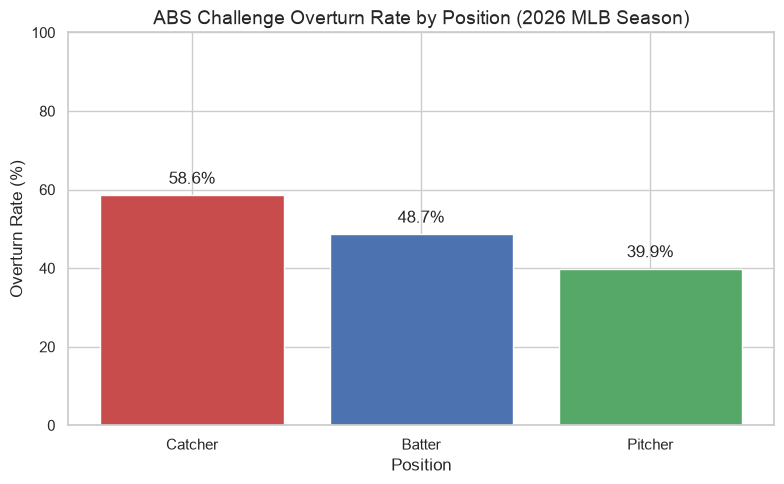

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

positions = challenge_df[challenge_df["Pos"] != "Total"].copy()
positions["Pos"] = positions["Pos"].str.title()

ax.bar(positions["Pos"], positions["Overturn%"],
       color=["#c94c4c", "#4c72b0", "#55a868"])

ax.set_title("ABS Challenge Overturn Rate by Position (2026 MLB Season)", fontsize=14)
ax.set_xlabel("Position")
ax.set_ylabel("Overturn Rate (%)")
ax.set_ylim(0, 100)

ax.set_xticks(range(len(positions["Pos"])))
ax.set_xticklabels(positions["Pos"].tolist())

for i, v in enumerate(positions["Overturn%"]):
    ax.text(i, v + 2, f"{v}%", ha="center", va="bottom")

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "overturn_by_position.png"), dpi=150)
plt.show()

This visualization diplays the success of each position who can challenge pitches in the MLB. Catchers are the best by a solid margin over batters (9.9%) and an even wider margin over pitchers (18%). Catchers have a much better understanding of the strike zone, as well as the best view of the zone as it is very similar to the one the umpires have. Pitchers having such a bad challenge success rate could be due to a couple of things. Emotions taking over and wanting strikes that are never really close. This paired with a much worse view of the zone compared to batters and catchers, lead to the very poor success rate on pitcher challenges. Batters hover around 50% for their challenge success rate which would not give a reason for coaches to tell their batters not to challenge. Batters should however be wary of when they decide to use their challenges. The situation should heavily play into whether or not a batter should decide to challenge a pitch.

## Visualization 2 — Distance of Pitches from Zone

Uses Statcast's `plate_x` / `plate_z` columns (pitch location in feet at the front of home plate). The pitches that are clutering towards the middle could be called "challengable pitches". 

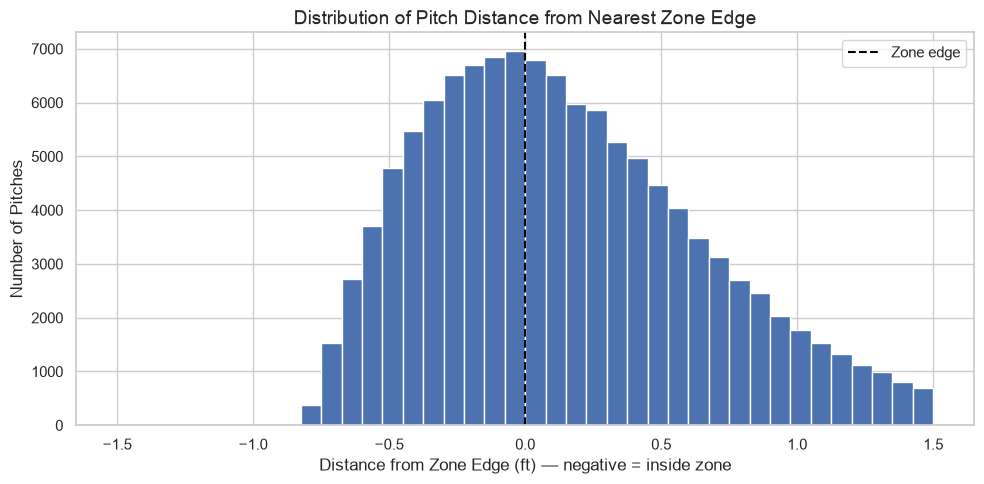

In [12]:
# Compute each pitch's signed distance from the nearest strike-zone edge.
# Horizontal edges are at x = -0.83 and x = 0.83 (ft from plate center).
# Vertical edges vary by batter height (sz_bot/sz_top columns in Statcast).

df = statcast_df.dropna(subset=["plate_x", "plate_z", "sz_bot", "sz_top"]).copy()

# Distance outside the horizontal boundary (0 if within the zone horizontally)
horiz_dist = df["plate_x"].abs() - 0.83

# Distance outside the vertical boundary (0 if within the zone vertically)
vert_dist = pd.concat([
    df["sz_bot"] - df["plate_z"],   # positive if below the zone
    df["plate_z"] - df["sz_top"]    # positive if above the zone
], axis=1).max(axis=1)

# Overall "distance from zone" - negative means inside the zone
df["zone_distance"] = pd.concat([horiz_dist, vert_dist], axis=1).max(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["zone_distance"], bins=40, range=(-1.5, 1.5), color="#4c72b0", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="Zone edge")
ax.set_title("Distribution of Pitch Distance from Nearest Zone Edge", fontsize=14)
ax.set_xlabel("Distance from Zone Edge (ft) — negative = inside zone")
ax.set_ylabel("Number of Pitches")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "zone_distance_histogram.png"), dpi=150)
plt.show()

Vizualization 2 provides context to the spread of pitches around the strike zone lie. The majority of the data points sit between -0.2 feet in the zone and 0.2 feet outside the zone. These are the pitches that umpires miss most frequently as there is such a small margin for error when determining in a split second whether or not a pitch was a strike. Pitches that lie outside of the range previously mentioned should be called correctly by an MLB level umpire every time. However if these pitches are wrongly called a ball or strike, ABS helps to ensure that these "non-borderline" pitches are checked and corrected. On the other hand, the borderline pitches and the ability to check an umpires call adds a new level of strategy and "game within the game" aspect to a sport that already has a lot of that to begin with.

In [13]:
print(len(statcast_df))
print(len(statcast_df)-len(df), "pitches were dropped due to missing data for plate_x, plate_z, sz_bot, or sz_top.")

121427
440 pitches were dropped due to missing data for plate_x, plate_z, sz_bot, or sz_top.


## 6. Data Cleaning Notes
Missing pitches:
Statcast pulled 121427 for the range of dates used, March 25, 2026 to April 25, 2026 or a month of games. Out of the 121427 pitches tracke, 440 rows were dropped (0.36%). This was due to missing sz_bot and sz_top values, which are both required to find the distance a pitch was from the zone. This amount of pitches is a negligable amount and can likely be attributed to extreme wild pitches that could fall outside our range. 


## 7. AI Transparency
Claude AI was used in order to keep my code effiecent and short. All of my data was obtained by me using the MLBStatsAPI along with baseball reference through pybaseball